In [ ]:
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

In [ ]:
path = '/Users/paul/Coding_Projects/Master/myocontrol_data_powergrasp2.mat'
mat = sp.io.loadmat(path)

In [ ]:
print("MAT keys:", list(mat.keys()))
for k in mat:
    if k.startswith('__'):
        continue
    print(k, type(mat[k]), getattr(mat[k], 'shape', 'no-shape'))

In [ ]:
# Extract and inspect EMG data (if present). This cell replaces the unfinished `emg =` line.
if 'EMG' in mat:
    emg_raw = mat['EMG']
    print("EMG raw type:", type(emg_raw))
    emg = np.array(emg_raw)
    print("EMG shape after np.array:", emg.shape)

    # Heuristic: prefer shape (n_samples, n_channels). If transpose needed, do it.
    if emg.ndim == 2:
        # If there are fewer rows than columns, assume shape is (n_channels, n_samples) and transpose
        if emg.shape[0] < emg.shape[1]:
            emg = emg.T
            print("Transposed EMG to shape (samples, channels):", emg.shape)
        else:
            print("EMG shape interpreted as (samples, channels):", emg.shape)

        # Create a DataFrame with channel names
        ch_names = [f'ch{i+1}' for i in range(emg.shape[1])]
        df_emg = pd.DataFrame(emg, columns=ch_names)

        print("DataFrame head:")
        display(df_emg.head())

        # OPTION: exclude bad channels (manual list)
        # Example: to exclude channel 17, set bad_channels=['ch17']
        bad_channels = ['ch17']  # <-- edit this list to exclude channels you know are bad

        # OPTIONAL: automatic detection (set to True to enable)
        auto_detect_bad = False
        # simple auto-detection rules: too many NaNs or near-zero std
        auto_nan_frac_threshold = 0.05
        auto_std_threshold = 1e-8

        # Identify manual bad channels that exist in the DataFrame
        bad_in_df = [ch for ch in bad_channels if ch in df_emg.columns]

        # If auto-detect requested, find channels with many NaNs or extremely low std
        if auto_detect_bad:
            nan_frac = df_emg.isna().mean()
            low_std = df_emg.std().abs() < auto_std_threshold
            auto_bad = list(nan_frac[nan_frac > auto_nan_frac_threshold].index) + list(low_std[low_std].index)
            # avoid duplicates
            for ch in auto_bad:
                if ch not in bad_in_df:
                    bad_in_df.append(ch)

        if bad_in_df:
            print("Excluding bad channels:", bad_in_df)
            df_emg = df_emg.drop(columns=bad_in_df)
        else:
            print("No manual/auto bad channels to exclude.")

        # Sort channels (columns) by mean absolute amplitude (descending)
        col_order = df_emg.abs().mean().sort_values(ascending=False).index.tolist()
        df_sorted = df_emg[col_order]
        print("Columns sorted by mean absolute amplitude (desc):", col_order)
        display(df_sorted.head())

        # Show basic statistics
        print("Summary statistics:")
        display(df_sorted.describe())

    else:
        print("EMG has ndim =", emg.ndim, "- cannot convert to 2D DataFrame automatically.\nEMG object repr:", repr(emg_raw)[:500])
else:
    print("No 'EMG' key in mat. Available keys:", [k for k in mat.keys() if not k.startswith('__')])


Plotting top 31 channels: ['ch3', 'ch4', 'ch20', 'ch19', 'ch5', 'ch21', 'ch23', 'ch2', 'ch9', 'ch6', 'ch22', 'ch18', 'ch7', 'ch24', 'ch25', 'ch10', 'ch26', 'ch8', 'ch32', 'ch27', 'ch31', 'ch28', 'ch30', 'ch29', 'ch1', 'ch11', 'ch12', 'ch16', 'ch15', 'ch14', 'ch13']


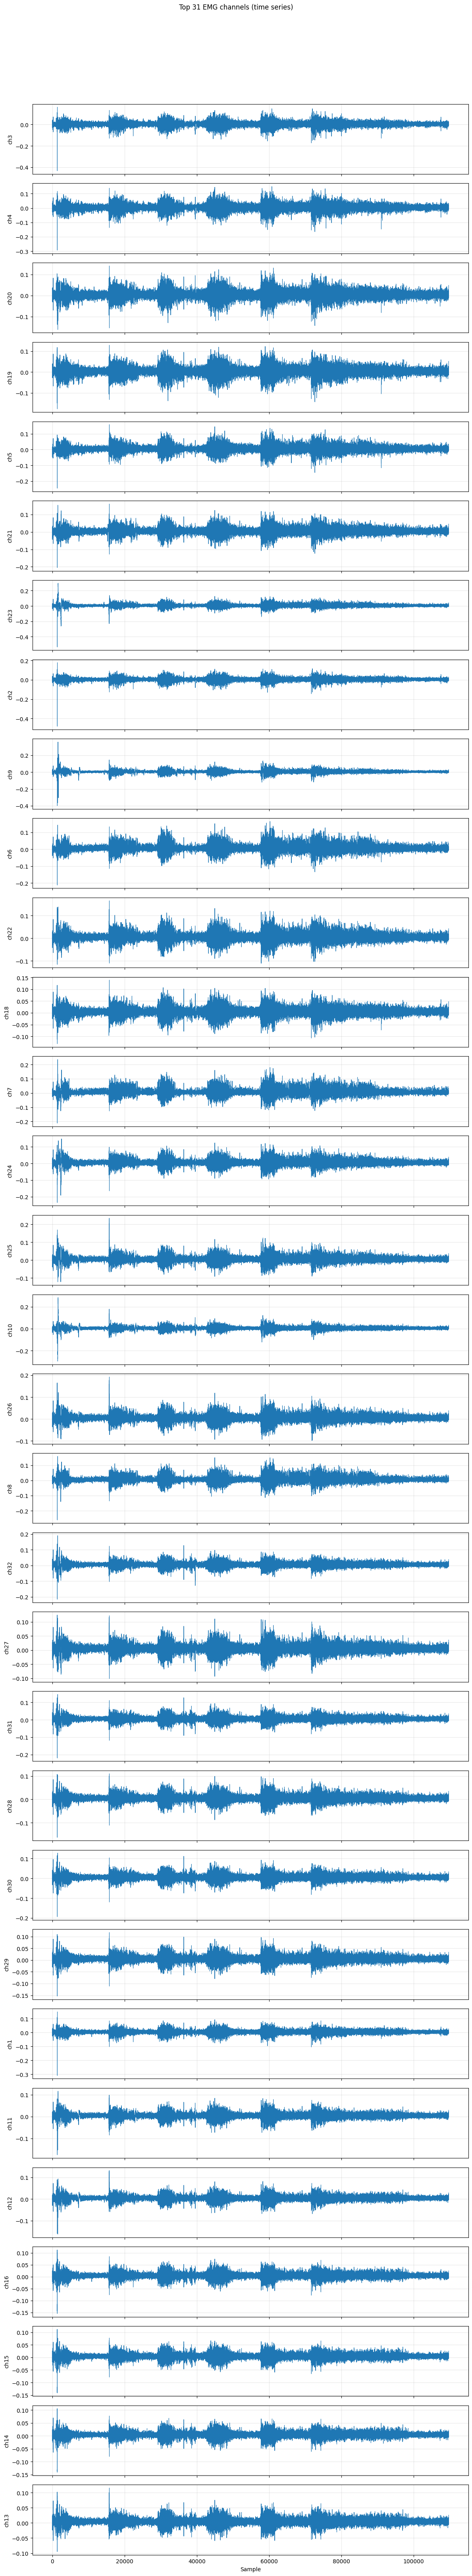

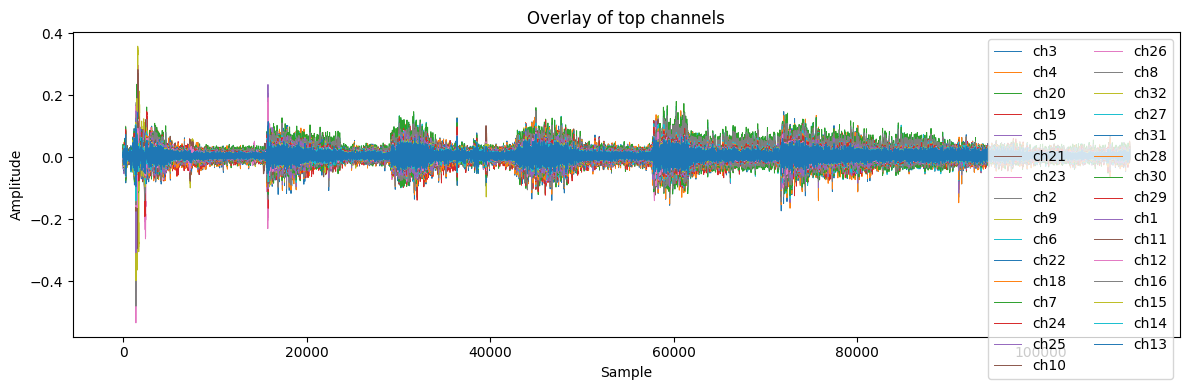

In [15]:
# Plot top N channels (time series). Adjust `N` to plot more/fewer channels.
# Use locals().get to avoid static analyzer warning about undefined name
df_emg = locals().get('df_emg', None)
if df_emg is None:
    print("df_emg not defined — run the EMG extraction cell first.")
else:
    N = 32  # change this to plot more/fewer channels
    # pick top N channels by mean absolute amplitude
    top_ch = df_emg.abs().mean().sort_values(ascending=False).index[:N].tolist()
    print(f"Plotting top {len(top_ch)} channels:", top_ch)

    t = np.arange(len(df_emg))
    nsub = len(top_ch)
    fig, axes = plt.subplots(nsub, 1, figsize=(12, 2.2*nsub), sharex=True)
    if nsub == 1:
        axes = [axes]
    for ax, ch in zip(axes, top_ch):
        ax.plot(t, df_emg[ch], linewidth=0.8)
        ax.set_ylabel(ch)
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel('Sample')
    plt.suptitle(f'Top {len(top_ch)} EMG channels (time series)')
    plt.tight_layout(rect=(0, 0.03, 1, 0.95))
    plt.show()

    # Optional: overlay all top channels in a single plot for comparison
    plt.figure(figsize=(12,4))
    for ch in top_ch:
        plt.plot(t, df_emg[ch], linewidth=0.7, label=ch)
    plt.legend(loc='upper right', ncol=2)
    plt.title('Overlay of top channels')
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    plt.show()


In [ ]:
''